In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras.layers import Dense
from keras.models import Sequential
from sklearn.model_selection import train_test_split
from keras.layers import Dropout
from sklearn.datasets import make_circles
from keras.callbacks import EarlyStopping
from pylab import rcParams
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
import warnings

In [3]:
X,y=make_circles(n_samples=100,noise=0.1,random_state=42)

<Axes: >

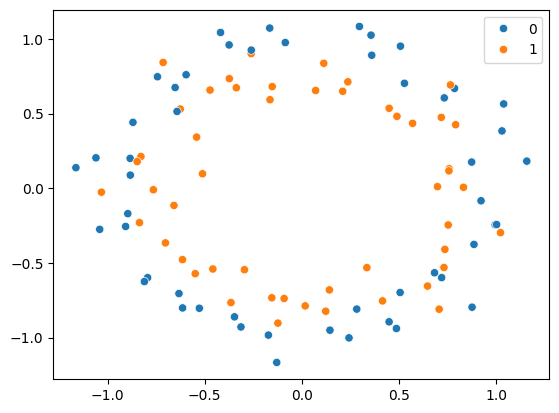

In [5]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
model=Sequential()
model.add(Dense(256,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'],optimizer='adam')

In [9]:
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),verbose=0,epochs=3500)

[]

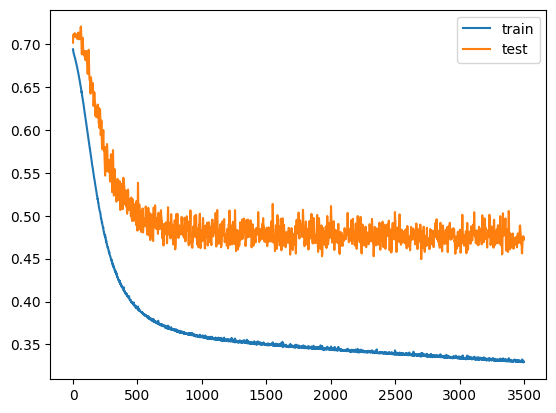

In [10]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.plot()

**Early Stopping**

In [11]:
model=Sequential()
model.add(Dense(256,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'],optimizer='adam')

In [17]:
callback=EarlyStopping(
    monitor='val_loss', #konse value pe chcek rakhnay..agar val_loss badhne lage ya fir koi chnages na ho tab early stopping training rokega
    patience=20,
    restore_best_weights=False,
    verbose=1,
    mode='auto',
    baseline=None,
    min_delta=0.00001
)

In [18]:
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),verbose=0,epochs=3500,callbacks=callback)

Epoch 186: early stopping


[]

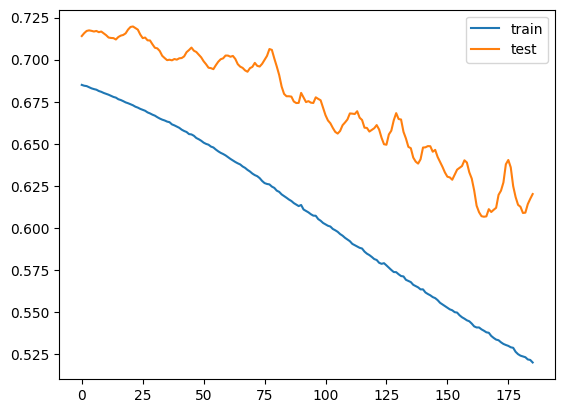

In [19]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.plot()